# LangSmith and Evaluation Overview with AI Makerspace

Today we'll be looking at an amazing tool:

[LangSmith](https://docs.smith.langchain.com/)!

This tool will help us monitor, test, debug, and evaluate our LangChain applications - and more!

We'll also be looking at a few Advanced Retrieval techniques along the way - and evaluate it using LangSmith!

✋BREAKOUT ROOM #2:
- Task 1: Dependencies and OpenAI API Key
- Task 2: LangGraph RAG
- Task 3: Setting Up LangSmith
- Task 4: Examining the Trace in LangSmith!
- Task 5: Create Testing Dataset
- Task 6: Evaluation

## Task 1: Dependencies and OpenAI API Key

We'll be using OpenAI's suite of models today to help us generate and embed our documents for our simple RAG system that leverages Loand Complaint data.

In [1]:
import os
import getpass

os.environ["OPENAI_API_KEY"] = getpass.getpass("Enter your OpenAI API Key:")

#### Asyncio Bug Handling

In [2]:
import nest_asyncio
nest_asyncio.apply()

## Task #2: Create a Simple RAG Application Using LangGraph

Let's remake our LangGraph RAG pipeline from the first notebook!

## LangGraph Powered RAG

First and foremost, LangChain provides a convenient way to store our chunks and their embeddings.

It's called a `VectorStore`!

We'll be using QDrant as our `VectorStore` today. You can read more about it [here](https://qdrant.tech/documentation/).

Think of a `VectorStore` as a smart way to house your chunks and their associated embedding vectors. The implementation of the `VectorStore` also allows for smarter and more efficient search of our embedding vectors - as the method we used above would not scale well as we got into the millions of chunks.

Otherwise, the process remains relatively similar under the hood!

### Data Collection

We'll be leveraging the `DirectoryLoader` to load our PDFs!

In [3]:
from langchain_community.document_loaders import DirectoryLoader
from langchain_community.document_loaders import PyMuPDFLoader

directory_loader = DirectoryLoader("data", glob="**/*.pdf", loader_cls=PyMuPDFLoader)

loan_knowledge_resources = directory_loader.load()

### Chunking Our Documents

Let's do the same process as we did before with our `RecursiveCharacterTextSplitter` - but this time we'll use ~200 tokens as our max chunk size!

In [5]:
import tiktoken
from langchain.text_splitter import RecursiveCharacterTextSplitter

def tiktoken_len(text):
    tokens = tiktoken.encoding_for_model("gpt-4o").encode(
        text,
    )
    return len(tokens)

text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 750,
    chunk_overlap = 0,
    length_function = tiktoken_len,
)
loan_knowledge_chunks = text_splitter.split_documents(loan_knowledge_resources)

In [7]:
len(loan_knowledge_chunks)

375

Let's verify the process worked as intended by checking our max document length.

In [8]:
max_chunk_length = 0

for chunk in loan_knowledge_chunks:
  max_chunk_length = max(max_chunk_length, tiktoken_len(chunk.page_content))

print(max_chunk_length)

742


Perfect! Now we can carry on to creating and storing our embeddings.

### Embeddings and Vector Storage

We'll use the `text-embedding-3-small` embedding model again - and `Qdrant` to store all our embedding vectors for easy retrieval later!

In [9]:
from langchain_community.vectorstores import Qdrant
from langchain_openai.embeddings import OpenAIEmbeddings

embedding_model = OpenAIEmbeddings(model="text-embedding-3-small")

qdrant_vectorstore = Qdrant.from_documents(
    documents=loan_knowledge_chunks,
    embedding=embedding_model,
    location=":memory:"
)

Now let's set up our retriever, just as we saw before, but this time using LangChain's simple `as_retriever()` method!

In [10]:
qdrant_retriever = qdrant_vectorstore.as_retriever()

#### Back to the Flow

We're ready to move to the next step!

### Setting up our RAG

We'll use the same LangGraph pipeline we created in the first notebook. 

Let's think through each part:

1. First we need to retrieve context
2. We need to pipe that context to our model
3. We need to parse that output

Let's start by setting up our prompt again, just so it's fresh in our minds!

#### 🏗️ Activity #2:

Complete the prompt so that your RAG application answers queries based on the context provided, but *does not* answer queries if the context is unrelated to the query.

In [11]:
from langchain_core.prompts import ChatPromptTemplate

HUMAN_TEMPLATE = """
#CONTEXT:
{context}

QUERY:
{query}

Use the provide context to answer the provided user query. Only use the provided context to answer the query. If you do not know the answer, or it's not contained in the provided context respond with "I don't know"
"""

chat_prompt = ChatPromptTemplate.from_messages([
    ("human", HUMAN_TEMPLATE)
])

We'll set our Generator - `gpt-4.1-nano` in this case - below!

In [12]:
from langchain_openai import ChatOpenAI

openai_chat_model = ChatOpenAI(model="gpt-4.1-nano")

#### Our RAG Application

Let's spin up the graph.

In [13]:
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
  question: str
  context: list[Document]
  response: str

def retrieve(state: State) -> State:
  retrieved_docs = qdrant_retriever.invoke(state["question"])
  return {"context" : retrieved_docs}

def generate(state: State) -> State:
  generator_chain = chat_prompt | openai_chat_model | StrOutputParser()
  response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
  return {"response" : response}

graph_builder = StateGraph(State)
graph_builder = graph_builder.add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")
rag_graph = graph_builder.compile()

Let's get a visual understanding of our chain!

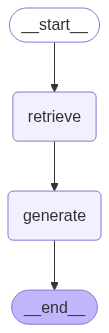

In [14]:
rag_graph

Let's test our chain out!

In [15]:
response = rag_graph.invoke({"question" : "Is applying for and securing a student loan in 2025 a terrible idea?"})

In [17]:
response["response"]

"Applying for and securing a student loan in 2025 is not necessarily a terrible idea based on the provided context. The documents emphasize the importance of understanding loan limits, the process of increasing loan amounts when a student's grade level progresses, and the need for proper counseling and documentation. They also highlight the benefits of planning and ensuring the student meets eligibility requirements, such as enrollment status and satisfactory academic progress. Properly managed, student loans can help finance education; however, it is important that students carefully consider their eligibility, the amount they borrow, and their repayment plans."

In [18]:
for context in response["context"]:
  print("Context:")
  print(context.page_content[:100])
  print("----")

Context:
student to earn that number of credits. For instance, if your school has a baccalaureate program tha
----
Context:
You must confirm that the borrower meets the definition of eligible borrower by doing the following:
----
Context:
Regardless of the counseling methods your school uses, it must document that the student received en
----
Context:
Pell Grant Lifetime Eligibility Used
Before awarding a Pell Grant, you must check the COD common rec
----


In [37]:
# Create the project explicitly before running traces
from langsmith import Client

client = Client()

# Create project if it doesn't exist
project_name = os.environ.get("LANGSMITH_PROJECT")
try:
    # Try to get the project
    project = client.read_project(project_name=project_name)
    print(f"✅ Project '{project_name}' already exists!")
except:
    # Create the project if it doesn't exist
    try:
        project = client.create_project(project_name=project_name)
        print(f"✅ Created new project: '{project_name}'")
        print(f"   Project ID: {project.id}")
    except Exception as e:
        print(f"❌ Error creating project: {str(e)}")
        print("\nTrying alternative project name...")
        # Try a simpler project name without spaces
        alt_project_name = f"langsmith-{unique_id}"
        os.environ["LANGSMITH_PROJECT"] = alt_project_name
        project = client.create_project(project_name=alt_project_name)
        print(f"✅ Created project with alternative name: '{alt_project_name}'")


✅ Created new project: 'LangSmith - 4ce1e9dd'
   Project ID: 9045be78-964b-457f-a346-f6cb53763819


In [38]:
# Test with a simple LangChain component first (not LangGraph)
# This will help us determine if the issue is with LangGraph specifically

from langchain_core.runnables import RunnableLambda

# Create a simple runnable
simple_chain = RunnableLambda(lambda x: f"Echo: {x}")

# Test it
result = simple_chain.invoke("Testing LangSmith tracing")
print(f"Result: {result}")
print("\nCheck if this simple trace appears in LangSmith!")


[chain/start] [chain:RunnableLambda] Entering Chain run with input:
{
  "input": "Testing LangSmith tracing"
}
[chain/end] [chain:RunnableLambda] s] Exiting Chain run with output:
{
  "output": "Echo: Testing LangSmith tracing"
}
Result: Echo: Testing LangSmith tracing

Check if this simple trace appears in LangSmith!


In [39]:
# Important: For LangGraph to work with LangSmith, we need to ensure tracing is enabled
# BEFORE creating the graph. Let's recreate the graph with tracing enabled

# First, let's verify all env vars are still set
print("Current LangSmith configuration:")
for key in ["LANGSMITH_TRACING", "LANGSMITH_ENDPOINT", "LANGSMITH_PROJECT", "LANGSMITH_API_KEY"]:
    value = os.environ.get(key, "NOT SET")
    if key == "LANGSMITH_API_KEY":
        print(f"{key}: {'SET' if value != 'NOT SET' else 'NOT SET'}")
    else:
        print(f"{key}: {value}")

# Now recreate the graph with tracing enabled
from langgraph.graph import START, StateGraph
from typing_extensions import TypedDict
from langchain_core.documents import Document
from langchain_core.output_parsers import StrOutputParser

class State(TypedDict):
    question: str
    context: list[Document]
    response: str

def retrieve(state: State) -> State:
    retrieved_docs = qdrant_retriever.invoke(state["question"])
    return {"context" : retrieved_docs}

def generate(state: State) -> State:
    generator_chain = chat_prompt | openai_chat_model | StrOutputParser()
    response = generator_chain.invoke({"query" : state["question"], "context" : state["context"]})
    return {"response" : response}

# Recreate the graph
graph_builder = StateGraph(State)
graph_builder = graph_builder.add_sequence([retrieve, generate])
graph_builder.add_edge(START, "retrieve")

# Compile with explicit name for tracing
rag_graph = graph_builder.compile(name="StudentLoanRAG")

print("\n✅ Graph recreated with tracing enabled!")


Current LangSmith configuration:
LANGSMITH_TRACING: true
LANGSMITH_ENDPOINT: https://api.smith.langchain.com
LANGSMITH_PROJECT: LangSmith - 4ce1e9dd
LANGSMITH_API_KEY: SET

✅ Graph recreated with tracing enabled!


In [40]:
# Test the recreated graph with explicit run name
import time
from langchain.callbacks.manager import collect_runs

# Method 1: Using collect_runs context manager
with collect_runs() as cb:
    response = rag_graph.invoke(
        {"question": "What is the maximum loan amount for graduate students?"},
        {"run_name": "test-rag-trace", "tags": ["langgraph-test"]}
    )
    run_id = cb.traced_runs[0].id if cb.traced_runs else None

print(f"Response: {response['response'][:150]}...")
if run_id:
    print(f"\n✅ Trace created with Run ID: {run_id}")
    print(f"View at: https://smith.langchain.com/public/{os.environ.get('LANGSMITH_PROJECT')}/r/{run_id}")
else:
    print("\n❌ No run ID captured")

# Give LangSmith time to process the trace
print("\nWaiting 5 seconds for trace to be processed...")
time.sleep(5)


[chain/start] [chain:test-rag-trace] Entering Chain run with input:
{
  "question": "What is the maximum loan amount for graduate students?"
}
[chain/start] [chain:test-rag-trace > chain:retrieve] Entering Chain run with input:
{
  "question": "What is the maximum loan amount for graduate students?"
}
[chain/end] [chain:test-rag-trace > chain:retrieve] s] Exiting Chain run with output:
[outputs]
[chain/start] [chain:test-rag-trace > chain:generate] Entering Chain run with input:
[inputs]
[chain/start] [chain:test-rag-trace > chain:generate > chain:RunnableSequence] Entering Chain run with input:
[inputs]
[chain/start] [chain:test-rag-trace > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] Entering Prompt run with input:
[inputs]
[chain/end] [chain:test-rag-trace > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] s] Exiting Prompt run with output:
[outputs]
[llm/start] [chain:test-rag-trace > chain:generate > chain:RunnableSequence > llm:ChatOpen

Let's see if it can handle a query that is totally unrelated to the source documents.

In [42]:
response = rag_graph.invoke({"question" : "What is the airspeed velocity of an unladen swallow?"})

[chain/start] [chain:StudentLoanRAG] Entering Chain run with input:
{
  "question": "What is the airspeed velocity of an unladen swallow?"
}
[chain/start] [chain:StudentLoanRAG > chain:retrieve] Entering Chain run with input:
{
  "question": "What is the airspeed velocity of an unladen swallow?"
}
[chain/end] [chain:StudentLoanRAG > chain:retrieve] s] Exiting Chain run with output:
[outputs]
[chain/start] [chain:StudentLoanRAG > chain:generate] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] Entering Prompt run with input:
[inputs]
[chain/end] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] s] Exiting Prompt run with output:
[outputs]
[llm/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > llm:ChatOpenAI] 

In [43]:
response["response"]

"I don't know"

## Task 3: Setting Up LangSmith

Now that we have a chain - we're ready to get started with LangSmith!

We're going to go ahead and use the following `env` variables to get our Colab notebook set up to start reporting.

If all you needed was simple monitoring - this is all you would need to do!

In [44]:
from uuid import uuid4

unique_id = uuid4().hex[0:8]

os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_ENDPOINT"] = "https://api.smith.langchain.com"
os.environ["LANGSMITH_PROJECT"] = f"LangSmith - {unique_id}"

### LangSmith API

In order to use LangSmith - you will need an API key. You can sign up for a free account on [LangSmith's homepage!](https://www.langchain.com/langsmith)

Once you have created your account, Take the navigation option for `Settings` then `API Keys` to create an API key.

In [29]:
os.environ["LANGSMITH_API_KEY"] = getpass.getpass('Enter your LangSmith API key: ')

In [30]:
# Debug: Verify LangSmith environment variables
print("LangSmith Configuration:")
print(f"LANGSMITH_TRACING: {os.environ.get('LANGSMITH_TRACING', 'NOT SET')}")
print(f"LANGSMITH_ENDPOINT: {os.environ.get('LANGSMITH_ENDPOINT', 'NOT SET')}")
print(f"LANGSMITH_PROJECT: {os.environ.get('LANGSMITH_PROJECT', 'NOT SET')}")
print(f"LANGSMITH_API_KEY: {'SET' if os.environ.get('LANGSMITH_API_KEY') else 'NOT SET'}")


LangSmith Configuration:
LANGSMITH_TRACING: true
LANGSMITH_ENDPOINT: https://api.smith.langchain.com
LANGSMITH_PROJECT: LangSmith - 9db636e3
LANGSMITH_API_KEY: SET


Let's test our our first generation!

In [31]:
# Test tracing with a simple query
test_response = rag_graph.invoke(
    {"question": "What is a student loan?"}, 
    {"tags": ["test-trace"], "metadata": {"test": True}}
)
print(f"Response received: {test_response['response'][:100]}...")
print("\nCheck your LangSmith dashboard for this trace!")


Response received: A student loan is a type of financial aid that helps students pay for their education. Specifically,...

Check your LangSmith dashboard for this trace!


In [32]:
# Advanced debugging - Check LangSmith client
from langsmith import Client

try:
    # Test connection to LangSmith
    ls_client = Client()
    # List projects to verify connection
    projects = list(ls_client.list_projects(limit=5))
    print(f"✅ Successfully connected to LangSmith!")
    print(f"Found {len(projects)} projects")
    
    # Check if our project exists
    current_project = os.environ.get("LANGSMITH_PROJECT")
    project_exists = any(p.name == current_project for p in projects)
    print(f"Current project '{current_project}': {'EXISTS' if project_exists else 'WILL BE CREATED'}")
    
except Exception as e:
    print(f"❌ Error connecting to LangSmith: {str(e)}")
    print("\nPossible causes:")
    print("1. Invalid API key")
    print("2. Network connectivity issues")
    print("3. LangSmith service issues")


✅ Successfully connected to LangSmith!
Found 1 projects
Current project 'LangSmith - 9db636e3': WILL BE CREATED


In [45]:
# Force enable tracing for LangChain components
import langchain
from langchain.callbacks.manager import tracing_v2_enabled

# Enable debug mode to see more detailed logs
langchain.debug = True

# Verify tracing is enabled
print(f"LangChain debug mode: {langchain.debug}")
print(f"Tracing enabled: {tracing_v2_enabled()}")

# Alternative: You can also wrap your invocation with explicit tracing
from langchain.callbacks.tracers import LangChainTracer

tracer = LangChainTracer()
response_with_tracer = rag_graph.invoke(
    {"question": "What are the eligibility requirements for student loans?"}, 
    config={"callbacks": [tracer], "tags": ["explicit-tracer-test"]}
)
print(f"\nResponse with explicit tracer: {response_with_tracer['response'][:100]}...")


LangChain debug mode: True
Tracing enabled: <contextlib._GeneratorContextManager object at 0x17572d3a0>
[chain/start] [chain:StudentLoanRAG] Entering Chain run with input:
{
  "question": "What are the eligibility requirements for student loans?"
}
[chain/start] [chain:StudentLoanRAG > chain:retrieve] Entering Chain run with input:
{
  "question": "What are the eligibility requirements for student loans?"
}
[chain/end] [chain:StudentLoanRAG > chain:retrieve] s] Exiting Chain run with output:
[outputs]
[chain/start] [chain:StudentLoanRAG > chain:generate] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] Entering Prompt run with input:
[inputs]
[chain/end] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] s] Exiting Prompt run with 

In [48]:
rag_graph.invoke({"question" : "What is the maximum loan amount I can get from the government to go to school these days?"}, {"tags" : ["Demo Run"]})['response']

[chain/start] [chain:StudentLoanRAG] Entering Chain run with input:
{
  "question": "What is the maximum loan amount I can get from the government to go to school these days?"
}
[chain/start] [chain:StudentLoanRAG > chain:retrieve] Entering Chain run with input:
{
  "question": "What is the maximum loan amount I can get from the government to go to school these days?"
}
[chain/end] [chain:StudentLoanRAG > chain:retrieve] s] Exiting Chain run with output:
[outputs]
[chain/start] [chain:StudentLoanRAG > chain:generate] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] Entering Prompt run with input:
[inputs]
[chain/end] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] s] Exiting Prompt run with output:
[outputs]
[llm/start] [chain:S

"Based on the provided context, the maximum loan amount you can receive from the government for an undergraduate program depends on your academic year and grade level. \n\n- For example, a dependent second-year undergraduate can get up to $6,500 annually, with no more than $4,500 of that being subsidized. If your academic status changes during the year, your eligibility may be adjusted accordingly, up to a maximum of $7,500 for third-year and beyond dependent undergraduates, with specific subsidized limits.\n\n- For shorter programs, such as a 900 clock-hour program, the prorated annual loan limit can be calculated based on the hours completed. For instance, if a student completes only 750 hours out of a 900-hour program, the prorated loan limit could be approximately $4,583, with restrictions on subsidized amounts.\n\n- The overall aggregate limits for loans, including both subsidized and unsubsidized, are:\n  - $31,000 for dependent undergraduates (excluding those whose parents can't

## Task 4: Examining the Trace in LangSmith!

Head on over to your LangSmith web UI to check out how the trace looks in LangSmith!

#### 🏗️ Activity #1:

Include a screenshot of your trace and explain what it means.

Below is the screenshot of my trace. It means that we have retrieve and generate notes within the LangGraph graph. The retrieve node executed the VectorStoreRetriever to extract relevant chunks and the generate node used Open AI's LLM to template the user prompt, structure the input and reformat the output.

![langsmith_screenshot.png](langsmith_screenshot.png)

## Task 5: Loading Our Testing Set

In [49]:
!git clone https://github.com/AI-Maker-Space/DataRepository.git

fatal: destination path 'DataRepository' already exists and is not an empty directory.


In [50]:
import pandas as pd

test_df = pd.read_csv("DataRepository/student_loan_rag_test_data.csv")

Now we can set up our LangSmith client - and we'll add the above created dataset to our LangSmith instance!

> NOTE: Read more about this process [here](https://docs.smith.langchain.com/old/evaluation/faq/manage-datasets#create-from-list-of-values)

In [51]:
from langsmith import Client

client = Client()

dataset_name = "langsmith-student-loan-rag"

dataset = client.create_dataset(
    dataset_name=dataset_name, description="Student Loan RAG Test Questions"
)

for triplet in test_df.iterrows():
  triplet = triplet[1]
  client.create_example(
      inputs={"question" : triplet["question"], "context": triplet["context"]},
      outputs={"answer" : triplet["answer"]},
      dataset_id=dataset.id
  )

## Task 6: Evaluation

Now we can run the evaluation!

We'll need to start by preparing some custom data preparation functions to ensure our chain works with the expected inputs/outputs from the `evaluate` process in LangSmith.

> NOTE: More reading on this available [here](https://docs.smith.langchain.com/how_to_guides/evaluation/evaluate_llm_application#evaluate-a-langchain-runnable)

In [52]:
def prepare_data_ref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "reference" : example.outputs["answer"],
      "input" : example.inputs["question"]
  }

def prepare_data_noref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "input" : example.inputs["question"]
  }

def prepare_context_ref(run, example):
  return {
      "prediction" : run.outputs["response"],
      "reference" : example.inputs["context"],
      "input" : example.inputs["question"]
  }

We'll be using a few custom evaluators to evaluate our pipeline, as well as a few "built in" methods!

Check out the built-ins [here](https://docs.smith.langchain.com/reference/sdk_reference/langchain_evaluators)!

In [ ]:
from langsmith.evaluation import LangChainStringEvaluator, evaluate

eval_llm = ChatOpenAI(model="gpt-4o-mini", tags=["eval_llm"])

cot_qa_evaluator = LangChainStringEvaluator("cot_qa",  config={"llm":eval_llm}, prepare_data=prepare_context_ref)

unlabeled_dopeness_evaluator = LangChainStringEvaluator(
    "criteria",
    config={
        "criteria" : {
            "dopeness" : "Is the answer to the question dope, meaning cool - awesome - and legit?"
        },
        "llm" : eval_llm,
    },
    prepare_data=prepare_data_noref
)

labeled_score_evaluator = LangChainStringEvaluator(
    "labeled_score_string",
    config={
        "criteria": {
            "accuracy": "Is the generated answer the same as the reference answer?"
        },
    },
    prepare_data=prepare_data_ref
)

base_rag_results = evaluate(
    rag_graph.invoke,
    data=dataset_name,
    evaluators=[
        cot_qa_evaluator,
        unlabeled_dopeness_evaluator,
        labeled_score_evaluator,
        ],
    experiment_prefix="Base RAG Evaluation"
)

View the evaluation results for experiment: 'Base RAG Evaluation-beac943b' at:
https://smith.langchain.com/o/4e8d6936-58a0-4ff9-bfae-6484988e5784/datasets/15b8216b-709f-461c-b70a-f9ff3128f464/compare?selectedSessions=2f9e2977-2e90-4efc-ac77-bdf2c296bf18




0it [00:00, ?it/s]

[chain/start] [chain:StudentLoanRAG] Entering Chain run with input:
{
  "context": "Applications_and_Verification_Guide.pdf",
  "question": "What does 'verification' mean in the FAFSA process?"
}
[chain/start] [chain:StudentLoanRAG > chain:retrieve] Entering Chain run with input:
{
  "question": "What does 'verification' mean in the FAFSA process?",
  "context": "Applications_and_Verification_Guide.pdf"
}
[chain/end] [chain:StudentLoanRAG > chain:retrieve] [1.40s] Exiting Chain run with output:
[outputs]
[chain/start] [chain:StudentLoanRAG > chain:generate] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence] Entering Chain run with input:
[inputs]
[chain/start] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] Entering Prompt run with input:
[inputs]
[chain/end] [chain:StudentLoanRAG > chain:generate > chain:RunnableSequence > prompt:ChatPromptTemplate] s] Exiting Prompt run wi

#### ❓Question #1:

What conclusions can you draw about the above results? Describe in your own words what the metrics are expressing.

It appears that all of the answers were marked correct using CoT context, the dopeness factor is inconsistent, sometimes dope, sometimes not.
The CotQAEvalChain measures the correctness, or factual accuracy of the response. 
The CriteriaEvalChain assesses the response on subjective criteria, like dopeness. On clarity, relevance, detail and tone, the tone of dopeness failed to be present in many responses.